# EDA: Walmart Store Sales Forecasting

Разведочный анализ перед моделированием. Смотрю на сезонность, эффект праздников,
разброс между магазинами разного типа и качество внешних регрессоров.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:.1f}'.format

train = pd.read_csv('data/train.csv', parse_dates=['Date'])
features = pd.read_csv('data/features.csv', parse_dates=['Date'])
stores = pd.read_csv('data/stores.csv')

df = train.merge(features.drop(columns=['IsHoliday']), on=['Store', 'Date'], how='left')
df = df.merge(stores, on='Store', how='left')
df.shape

(421570, 16)

## Общая картина

In [2]:
df.describe()[['Weekly_Sales']]

,Weekly_Sales
count,421570.0
mean,15981.3
min,-4988.9
25%,2079.6
50%,7612.0
75%,20205.9
max,693099.4
std,22711.2


In [3]:
print('отрицательные продажи (возвраты):', (df.Weekly_Sales < 0).sum())
print('доля праздничных недель:', df.IsHoliday.mean().round(3))
print('диапазон дат:', df.Date.min().date(), '-', df.Date.max().date())

отрицательные продажи (возвраты): 1285
доля праздничных недель: 0.07
диапазон дат: 2010-02-05 - 2012-10-26


Отрицательные значения — это не ошибка, а недели с превышением возвратов над продажами
в конкретном отделе. Оставляю как есть, только клипую совсем экстремальные выбросы
в пайплайне обучения.

## Суммарные продажи по неделям

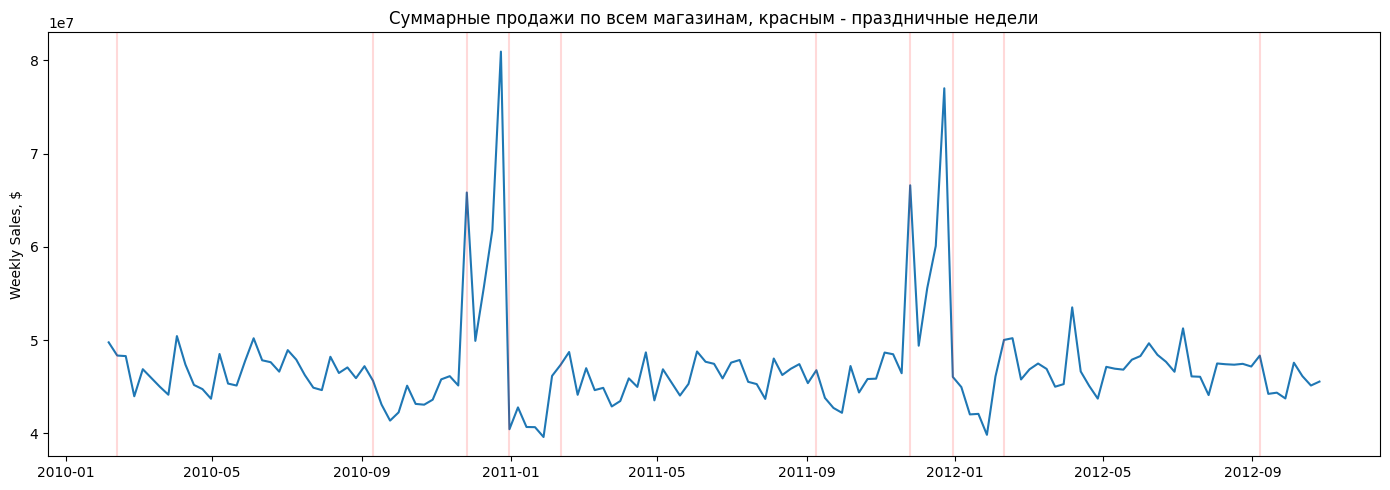

In [4]:
weekly = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly.values)
for date in df.loc[df.IsHoliday == 1, 'Date'].unique():
    plt.axvline(pd.Timestamp(date), color='red', alpha=0.15)
plt.title('Суммарные продажи по всем магазинам, красным - праздничные недели')
plt.ylabel('Weekly Sales, $')
plt.tight_layout()
plt.show()

Пики совпадают с предпраздничными неделями (Thanksgiving, Christmas) - логично,
это основной драйвер сезонности, который нужно поймать фичами.

## Праздники vs обычные недели

In [5]:
holiday_avg = df.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'median'])
holiday_avg.index = ['обычная неделя', 'праздничная неделя']
holiday_avg

,mean,median
обычная неделя,15901.4,7589.9
праздничная неделя,17035.8,7947.7


## Тип магазина и размер

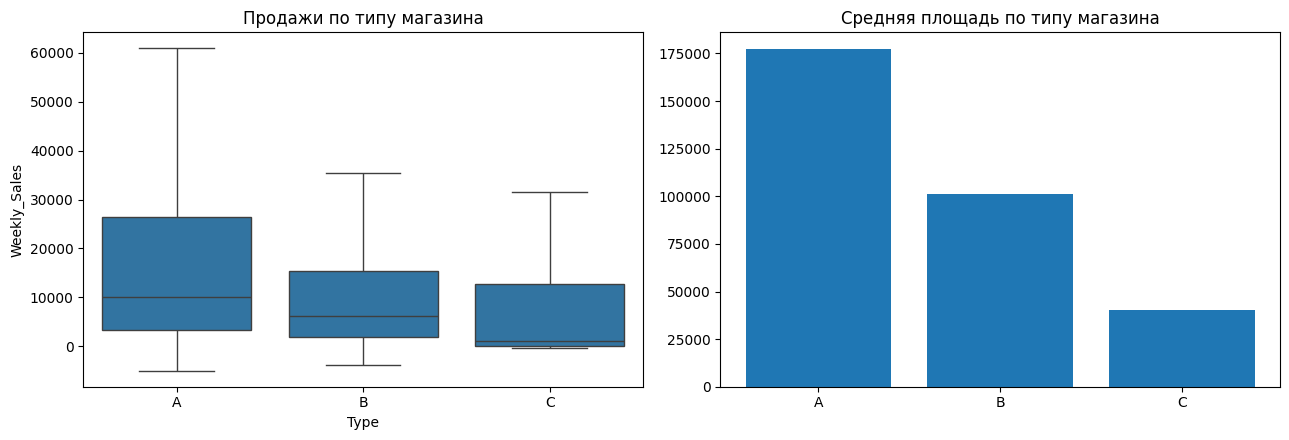

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x='Type', y='Weekly_Sales', order=['A', 'B', 'C'], ax=axes[0], showfliers=False)
axes[0].set_title('Продажи по типу магазина')

store_size = stores.groupby('Type')['Size'].mean()
axes[1].bar(store_size.index, store_size.values)
axes[1].set_title('Средняя площадь по типу магазина')

plt.tight_layout()
plt.show()

Тип магазина коррелирует с площадью и почти линейно с медианными продажами -
A крупнее и продаёт больше B, B больше C. Это ожидаемо и полезно как фича,
но большую часть вариации всё равно объясняет конкретный Store/Dept, а не тип.

## Разброс между отделами

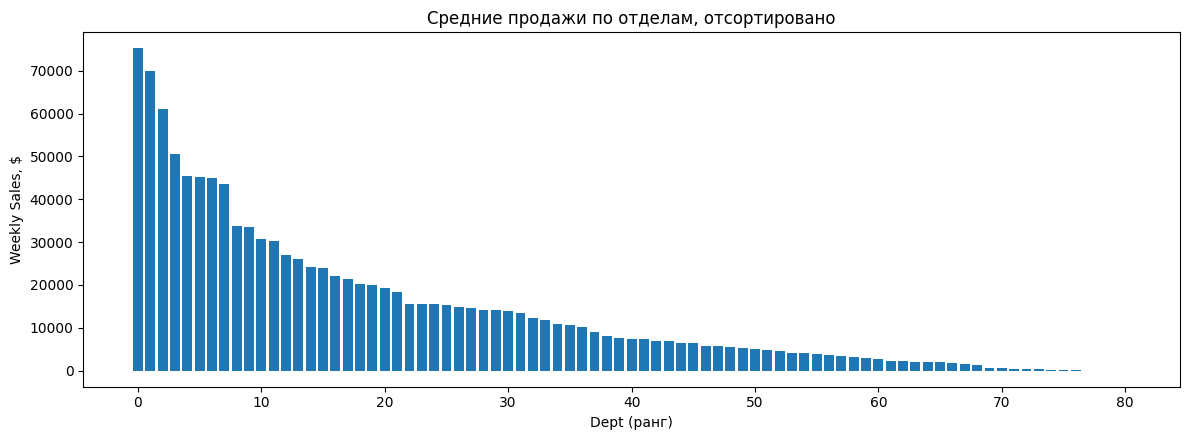

топ-5 отделов по продажам: [92, 95, 38, 72, 65]
разброс между отделами: от -7 до 75204


In [7]:
dept_avg = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4.5))
plt.bar(range(len(dept_avg)), dept_avg.values)
plt.title('Средние продажи по отделам, отсортировано')
plt.xlabel('Dept (ранг)')
plt.ylabel('Weekly Sales, $')
plt.tight_layout()
plt.show()

print('топ-5 отделов по продажам:', dept_avg.head(5).index.tolist())
print('разброс между отделами: от', int(dept_avg.min()), 'до', int(dept_avg.max()))

Разброс между отделами на порядки больше, чем между типами магазинов - это
главный аргумент в пользу того, чтобы CatBoost получал Store и Dept напрямую
как категориальные признаки, а не терял эту информацию в агрегатах.

## Внешние регрессоры и маркдауны

In [8]:
markdown_cols = [c for c in df.columns if c.startswith('MarkDown')]
print('доля пропусков по маркдаунам:')
print((df[markdown_cols].isna().mean() * 100).round(1))

доля пропусков по маркдаунам:
MarkDown1   64.3
MarkDown2   73.6
MarkDown3   67.5
MarkDown4   68.0
MarkDown5   64.1
dtype: float64


Маркдауны отсутствуют почти в 50% строк — это не пропуски измерения, а период
до ноября 2011, когда акции такого типа Walmart ещё не проводил. В пайплайне
заполняю нулями, а не медианой, потому что смысл именно такой - акции не было.

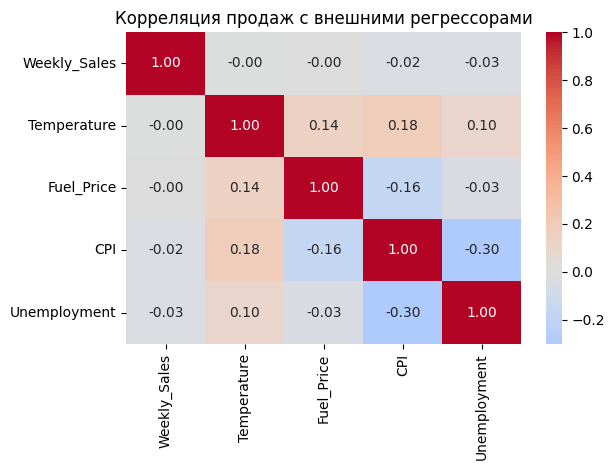

In [9]:
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляция продаж с внешними регрессорами')
plt.tight_layout()
plt.show()

Прямой линейной корреляции с погодой, топливом, CPI и безработицей почти нет -
ожидаемо, эти признаки работают не сами по себе, а в связке с сезонностью
и типом магазина, что как раз хорошо ловит бустинг.